# Bài Tập Lập Trình — Xử lý ảnh số
## Chương 3 & 4: Phát hiện cạnh, Phân đoạn ảnh

### Hướng dẫn chọn bài

Sinh viên làm **đúng 2 bài** — một bài từ mỗi nhóm:

| Nhóm | Chọn **1 trong 2** | Điểm |
|------|-------------------|------|
| **Nhóm A** (Chương 3) | Bài 1 — Canny *hoặc* Bài 2 — Harris | 50 |
| **Nhóm B** (Chương 4) | Bài 3 — Split & Merge *hoặc* Bài 4 — Mean-Shift | 50 |

> **Cách dùng notebook này:** Scroll đến bài bạn chọn và chỉ chạy các cell thuộc bài đó. Các cell của bài không chọn có thể bỏ qua.

---

**Yêu cầu:** `numpy`, `matplotlib`, `scipy`, `opencv-python`

**Quy ước:**
- `# TODO` — bạn phải viết code tại đây
- `# GIVEN` — code được cung cấp sẵn, không cần sửa (nhưng hãy đọc hiểu)
- `# TEST` — cell kiểm tra, chạy sau khi hoàn thành TODO

In [1]:
# GIVEN — Import và cài đặt chung
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import convolve, gaussian_filter
import cv2

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

print('✓ Thư viện đã sẵn sàng.')

✓ Thư viện đã sẵn sàng.


---
# Bài 1 — Tự cài đặt bộ lọc Canny

Cài đặt hàm `my_canny(image, sigma, t_low, t_high)` với bốn bước:
1. Làm mịn Gaussian
2. Tính gradient (Sobel)
3. Non-maximum suppression
4. Hysteresis thresholding

**Thư viện được phép:** `numpy`, `matplotlib`, `scipy.ndimage.convolve`  
**Cấm:** `cv2.Canny`, `skimage.feature.canny`, `scipy.ndimage.sobel`

## Bước 1 — Làm mịn Gaussian

Tạo Gaussian kernel 2D và thực hiện convolution với ảnh đầu vào.


In [2]:
def make_gaussian_kernel(sigma):
    """
    Tạo Gaussian kernel 2D chuẩn hóa.
    Kích thước kernel: (2 * ceil(3*sigma) + 1) x (2 * ceil(3*sigma) + 1)

    Tham số:
        sigma (float): độ lệch chuẩn của Gaussian
    Trả về:
        kernel (ndarray): Gaussian kernel 2D, tổng = 1
    """
    # TODO
    half   = int(np.ceil(3 * sigma))        # số pixel mỗi phía tính từ tâm
    size   = 2 * half + 1                   # kích thước cạnh kernel
    ax     = np.arange(-half, half + 1)     # vector tọa độ 1D
    xx, yy = np.meshgrid(ax, ax)            # lưới tọa độ 2D
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))   # Gaussian chưa chuẩn hóa
    kernel = kernel / kernel.sum()          # chuẩn hóa: tổng = 1
    return kernel


✓ make_gaussian_kernel: kích thước (7, 7), tổng = 1.000000


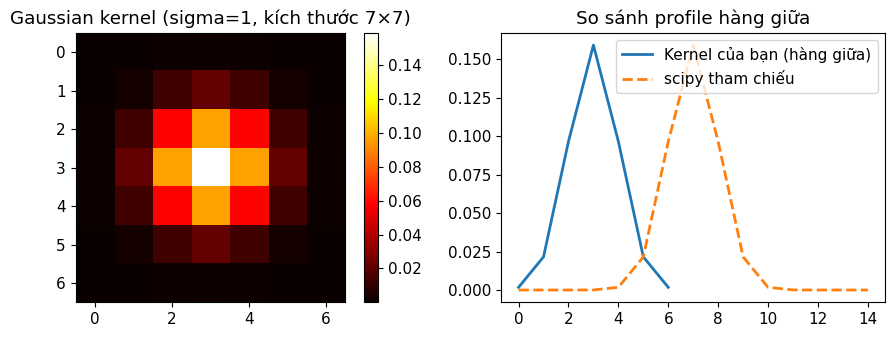

In [3]:
# TEST — Kiểm tra make_gaussian_kernel
k = make_gaussian_kernel(sigma=1.0)
assert k is not None, 'Hàm chưa trả về kết quả'
assert k.ndim == 2, f'Kernel phải là 2D, nhận được {k.ndim}D'
assert k.shape[0] == k.shape[1], 'Kernel phải vuông'
assert k.shape[0] == 7, f'Với sigma=1, kích thước phải là 7, nhận được {k.shape[0]}'
assert abs(k.sum() - 1.0) < 1e-6, f'Tổng kernel phải = 1, nhận được {k.sum():.6f}'
assert k[k.shape[0]//2, k.shape[1]//2] == k.max(), 'Giá trị lớn nhất phải ở tâm'
print(f'✓ make_gaussian_kernel: kích thước {k.shape}, tổng = {k.sum():.6f}')

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(k, cmap='hot')
axes[0].set_title(f'Gaussian kernel (sigma=1, kích thước {k.shape[0]}×{k.shape[1]})')
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])

# So sánh với scipy
from scipy.ndimage import gaussian_filter
delta = np.zeros((15, 15)); delta[7, 7] = 1.0
ref = gaussian_filter(delta, sigma=1.0)
axes[1].plot(k[k.shape[0]//2], label='Kernel của bạn (hàng giữa)', lw=2)
axes[1].plot(ref[7], '--', label='scipy tham chiếu', lw=2)
axes[1].set_title('So sánh profile hàng giữa')
axes[1].legend()
plt.tight_layout()
plt.show()

## Bước 2 — Tính gradient bằng Sobel

Tạo kernel Sobel 3×3 thủ công và dùng `scipy.ndimage.convolve`.


In [4]:
def compute_gradient(image):
    """
    Tính gradient ảnh bằng kernel Sobel 3x3.

    Tham số:
        image (ndarray): ảnh grayscale 2D, giá trị float
    Trả về:
        magnitude (ndarray): độ lớn gradient
        angle (ndarray): góc gradient (radian), trong [-pi, pi]
    """
    # TODO
    # Định nghĩa kernel Sobel theo hai chiều
    Sx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=float)   # phát hiện gradient ngang (x)
    Sy = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=float)  # phát hiện gradient dọc (y)

    Gx = convolve(image.astype(float), Sx)     # response theo chiều x
    Gy = convolve(image.astype(float), Sy)     # response theo chiều y

    magnitude = np.sqrt(Gx**2 + Gy**2)        # độ lớn gradient
    angle     = np.arctan2(Gy, Gx)             # góc trong [-pi, pi]
    return magnitude, angle


✓ compute_gradient: magnitude max=4.000


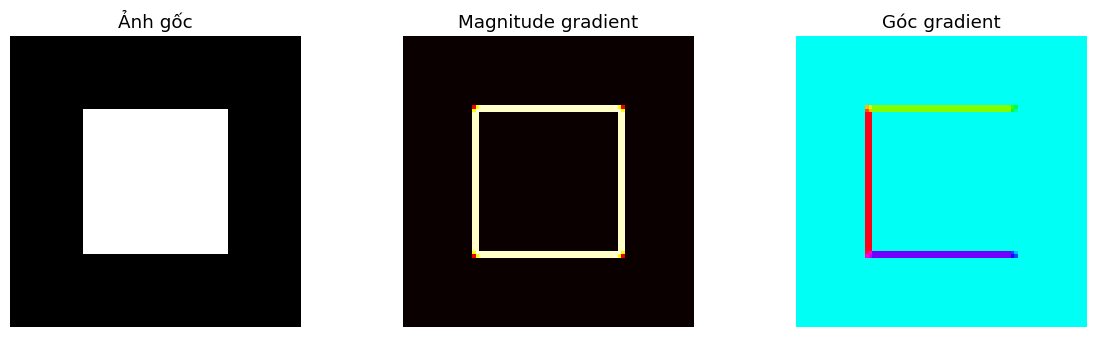

In [5]:
# TEST — Kiểm tra compute_gradient
test_img = np.zeros((20, 20), dtype=float)
test_img[:, 10:] = 1.0

result = compute_gradient(test_img)
assert result is not None, 'Hàm chưa trả về kết quả'
mag, ang = result
assert mag.shape == test_img.shape
assert ang.shape == test_img.shape
assert mag[:, 10].mean() > mag[:, 0].mean(), 'Gradient phải lớn nhất tại biên'
print(f'✓ compute_gradient: magnitude max={mag.max():.3f}')

test_rect = np.zeros((80, 80), dtype=float)
test_rect[20:60, 20:60] = 1.0
mag_rect, ang_rect = compute_gradient(test_rect)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(test_rect, cmap='gray'); axes[0].set_title('Ảnh gốc')
axes[1].imshow(mag_rect, cmap='hot'); axes[1].set_title('Magnitude gradient')
axes[2].imshow(ang_rect, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[2].set_title('Góc gradient')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


## Bước 3 — Non-Maximum Suppression (NMS)

Lượng tử hóa góc gradient về 4 hướng rời rạc. Tại mỗi pixel, chỉ giữ lại nếu nó là cực đại cục bộ theo hướng gradient của nó.


In [6]:
def non_maximum_suppression(magnitude, angle):
    """
    Làm mỏng cạnh bằng non-maximum suppression.

    Tham số:
        magnitude (ndarray): độ lớn gradient (H, W)
        angle (ndarray): góc gradient radian (H, W)
    Trả về:
        suppressed (ndarray): magnitude sau NMS,
                              pixels không phải cực đại bị đặt về 0
    """
    H, W = magnitude.shape
    suppressed = np.zeros_like(magnitude)
    # TODO
    # Chuyển góc sang độ tuyệt đối [0, 180) — hai chiều ngược nhau là cùng hướng
    angle_deg = np.abs(np.degrees(angle))

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            theta = angle_deg[i, j]

            # Xác định hai hàng xóm theo hướng gradient (4 hướng rời rạc)
            if theta < 22.5 or theta >= 157.5:       # 0°  — ngang
                n1, n2 = magnitude[i, j-1], magnitude[i, j+1]
            elif theta < 67.5:                        # 45° — chéo chính
                n1, n2 = magnitude[i-1, j-1], magnitude[i+1, j+1]
            elif theta < 112.5:                       # 90° — dọc
                n1, n2 = magnitude[i-1, j], magnitude[i+1, j]
            else:                                     # 135° — chéo phụ
                n1, n2 = magnitude[i-1, j+1], magnitude[i+1, j-1]

            # Giữ pixel nếu là cực đại cục bộ
            if magnitude[i, j] >= n1 and magnitude[i, j] >= n2:
                suppressed[i, j] = magnitude[i, j]

    return suppressed


✓ NMS: pixel cạnh trước=1248, sau=194 (giảm 84.5%)


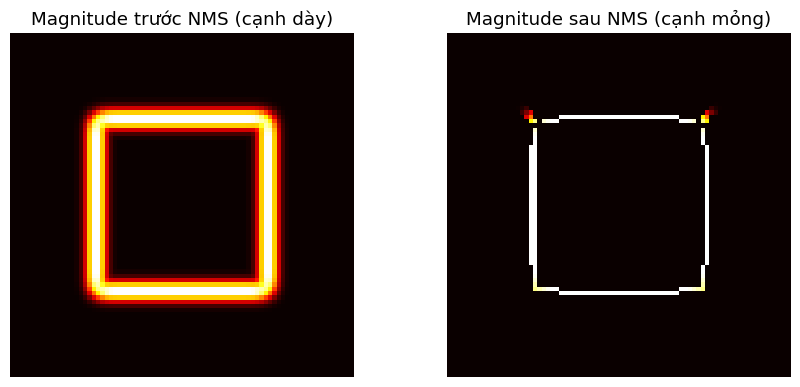

In [7]:
# TEST — Kiểm tra NMS
# Dùng kết quả gradient từ bước 2
gauss_k = make_gaussian_kernel(sigma=1.5)
smooth_rect = convolve(test_rect, gauss_k)
mag_s, ang_s = compute_gradient(smooth_rect)

nms_result = non_maximum_suppression(mag_s, ang_s)
assert nms_result is not None, 'Hàm chưa trả về kết quả'
assert nms_result.shape == mag_s.shape

# Sau NMS, số pixel khác 0 phải ít hơn trước NMS (đường cạnh mỏng hơn)
before = np.sum(mag_s > 0.1)
after  = np.sum(nms_result > 0.1)
assert after < before, f'NMS phải giảm số pixel cạnh: trước={before}, sau={after}'
print(f'✓ NMS: pixel cạnh trước={before}, sau={after} (giảm {100*(before-after)/before:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mag_s, cmap='hot')
axes[0].set_title('Magnitude trước NMS (cạnh dày)')
axes[1].imshow(nms_result, cmap='hot')
axes[1].set_title('Magnitude sau NMS (cạnh mỏng)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Bước 4 — Hysteresis Thresholding

- Pixel với `magnitude > t_high` → **cạnh chắc chắn** (strong)
- Pixel với `t_low < magnitude <= t_high` → **cạnh yếu** (weak)
- Cạnh yếu chỉ được giữ nếu 8-liên thông với ít nhất một cạnh chắc


In [8]:
def hysteresis_threshold(magnitude, t_low, t_high):
    """
    Áp dụng double thresholding và hysteresis.

    Tham số:
        magnitude (ndarray): magnitude sau NMS
        t_low (float): ngưỡng thấp
        t_high (float): ngưỡng cao
    Trả về:
        edges (ndarray): bản đồ cạnh nhị phân
    """
    # TODO
    H, W = magnitude.shape

    # Phân loại strong / weak
    strong = magnitude > t_high
    weak   = (magnitude > t_low) & (magnitude <= t_high)

    # Khởi tạo bản đồ cạnh từ các cạnh strong
    edges = strong.copy()

    # BFS: lan truyền từ strong sang weak 8-liên thông
    from collections import deque
    queue = deque(zip(*np.where(strong)))
    dirs  = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    while queue:
        i, j = queue.popleft()
        for di, dj in dirs:
            ni, nj = i + di, j + dj
            if 0 <= ni < H and 0 <= nj < W and weak[ni, nj] and not edges[ni, nj]:
                edges[ni, nj] = True
                queue.append((ni, nj))

    return edges


In [9]:
# TEST — Kiểm tra hysteresis thresholding
# Ví dụ nhỏ: một chuỗi pixel kết nối strong->weak->weak
test_mag = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.9, 0.6, 0.5, 0.0],  # 0.9=strong, 0.6 và 0.5=weak (nếu t_low=0.3, t_high=0.7)
    [0.0, 0.0, 0.0, 0.0, 0.0],
])
result_ht = hysteresis_threshold(test_mag, t_low=0.3, t_high=0.7)
assert result_ht is not None, 'Hàm chưa trả về kết quả'
assert result_ht[1, 1], 'Pixel strong phải là cạnh'
assert result_ht[1, 2], 'Pixel weak kề strong phải là cạnh'
assert result_ht[1, 3], 'Pixel weak kề weak-đã-kết-nối phải là cạnh'
print('✓ hysteresis_threshold: lan truyền cạnh hoạt động đúng')

# Kiểm tra: pixel yếu bị cô lập không được giữ
test_isolated = np.array([[0,0,0],[0,0.5,0],[0,0,0]], dtype=float)
res_iso = hysteresis_threshold(test_isolated, t_low=0.3, t_high=0.7)
assert not res_iso[1,1], 'Pixel weak cô lập KHÔNG được là cạnh'
print('✓ Pixel weak cô lập bị loại đúng')

✓ hysteresis_threshold: lan truyền cạnh hoạt động đúng
✓ Pixel weak cô lập bị loại đúng


## Tổng hợp — Hàm `my_canny`

In [10]:
def my_canny(image, sigma=1.0, t_low=0.05, t_high=0.15):
    """
    Canny edge detector hoàn chỉnh.

    Tham số:
        image  (ndarray): ảnh grayscale 2D (uint8 hoặc float)
        sigma  (float):   độ lệch chuẩn Gaussian
        t_low  (float):   ngưỡng thấp (tỉ lệ so với max magnitude)
        t_high (float):   ngưỡng cao
    Trả về:
        edges (ndarray): bản đồ cạnh nhị phân
    """
    img = image.astype(float)
    if img.max() > 1.0:
        img = img / 255.0
    # TODO
    # Bước 1 — Làm mịn Gaussian
    kernel   = make_gaussian_kernel(sigma)
    smoothed = convolve(img, kernel)

    # Bước 2 — Tính gradient Sobel
    magnitude, angle = compute_gradient(smoothed)

    # Chuẩn hóa ngưỡng theo max magnitude (t_low/t_high là tỉ lệ)
    mag_max = magnitude.max()
    tl = t_low  * mag_max if mag_max > 0 else t_low
    th = t_high * mag_max if mag_max > 0 else t_high

    # Bước 3 — Non-maximum suppression
    nms = non_maximum_suppression(magnitude, angle)

    # Bước 4 — Hysteresis thresholding
    edges = hysteresis_threshold(nms, tl, th)
    return edges


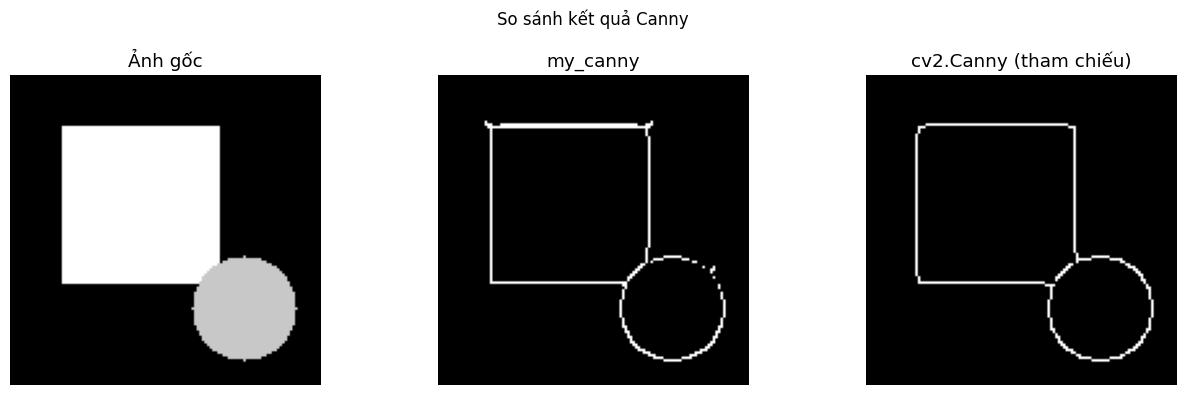

Kết quả không cần giống cv2.Canny hoàn toàn — nhưng cấu trúc cạnh phải tương đương.


In [11]:
# TEST — So sánh my_canny với cv2.Canny

# --- Ảnh test 1: hình tổng hợp ---
synth = np.zeros((120, 120), dtype=np.uint8)
cv2.rectangle(synth, (20, 20), (80, 80), 255, -1)
cv2.circle(synth, (90, 90), 20, 200, -1)

# --- Chạy my_canny ---
edges_mine = my_canny(synth, sigma=1.0, t_low=0.05, t_high=0.15)
assert edges_mine is not None, 'my_canny chưa trả về kết quả'

# --- Chạy cv2.Canny để so sánh trực quan ---
synth_blur = cv2.GaussianBlur(synth, (7, 7), 1.0)
edges_cv2 = cv2.Canny(synth_blur, threshold1=12, threshold2=36)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(synth, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[1].imshow(edges_mine, cmap='gray')
axes[1].set_title('my_canny')
axes[2].imshow(edges_cv2, cmap='gray')
axes[2].set_title('cv2.Canny (tham chiếu)')
for ax in axes: ax.axis('off')
plt.suptitle('So sánh kết quả Canny', fontsize=12)
plt.tight_layout()
plt.show()

print('Kết quả không cần giống cv2.Canny hoàn toàn — nhưng cấu trúc cạnh phải tương đương.')

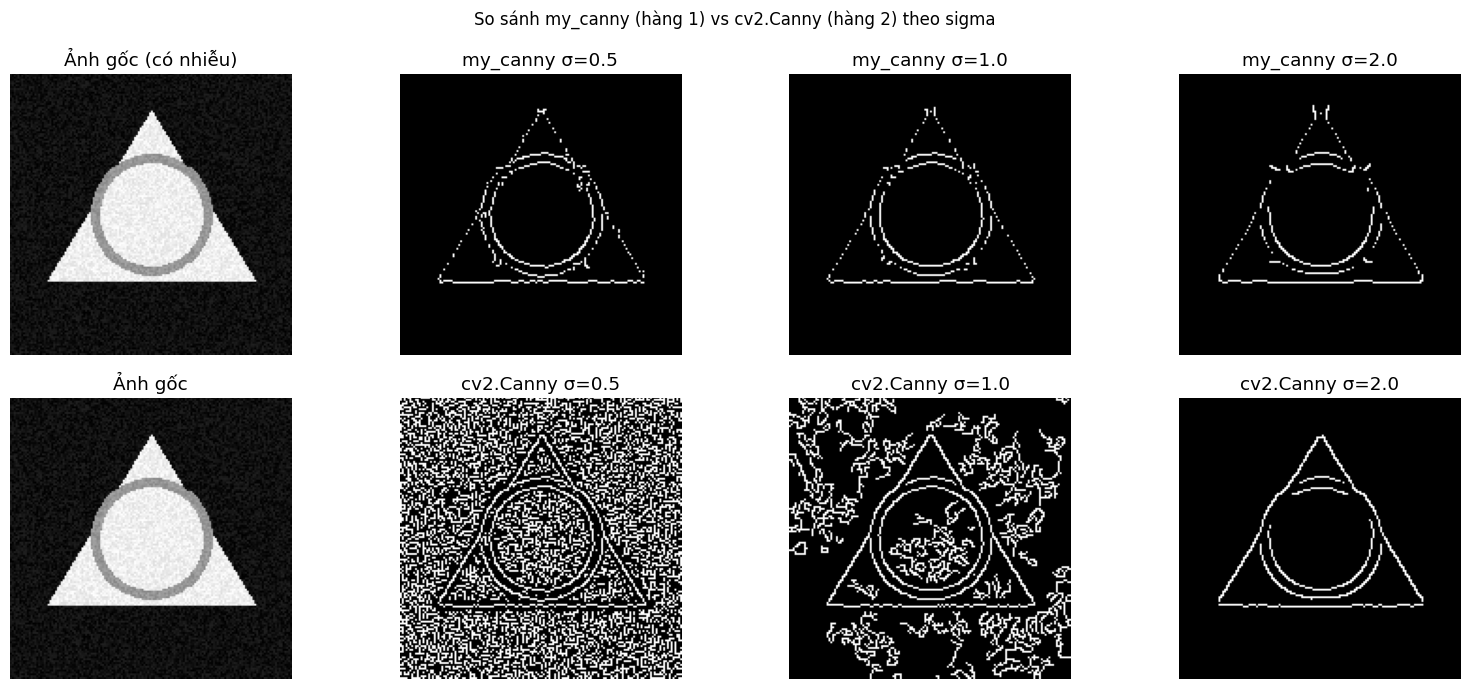

Nhận xét:
  σ nhỏ (0.5): ít làm mịn → giữ nhiều chi tiết, dễ bị ảnh hưởng bởi nhiễu
  σ lớn (2.0): làm mịn nhiều → cạnh mượt hơn, bỏ qua chi tiết nhỏ
  σ=1.0: cân bằng tốt giữa chi tiết và nhiễu


In [12]:
# TODO — Thử nghiệm với ít nhất 3 giá trị sigma trên cùng ảnh
# và so sánh trực quan kết quả my_canny với cv2.Canny

complex_synth = np.zeros((150, 150), dtype=np.uint8)
pts = np.array([[75,20],[130,110],[20,110]], dtype=np.int32)
cv2.fillPoly(complex_synth, [pts], 200)
cv2.circle(complex_synth, (75, 75), 30, 120, 3)
noise = np.random.randint(0, 30, complex_synth.shape, dtype=np.uint8)
complex_synth = np.clip(complex_synth.astype(int) + noise, 0, 255).astype(np.uint8)

sigmas = [0.5, 1.0, 2.0]
fig, axes = plt.subplots(2, len(sigmas) + 1, figsize=(16, 7))

# Hàng 1: my_canny với các sigma khác nhau
axes[0, 0].imshow(complex_synth, cmap='gray')
axes[0, 0].set_title('Ảnh gốc (có nhiễu)')
axes[0, 0].axis('off')

for ax, s in zip(axes[0, 1:], sigmas):
    result = my_canny(complex_synth, sigma=s, t_low=0.05, t_high=0.15)
    ax.imshow(result, cmap='gray')
    ax.set_title(f'my_canny σ={s}')
    ax.axis('off')

# Hàng 2: cv2.Canny với sigma tương ứng (để so sánh)
axes[1, 0].imshow(complex_synth, cmap='gray')
axes[1, 0].set_title('Ảnh gốc')
axes[1, 0].axis('off')

for ax, s in zip(axes[1, 1:], sigmas):
    ksize = 2 * int(np.ceil(3 * s)) + 1
    blurred = cv2.GaussianBlur(complex_synth, (ksize, ksize), s)
    ref = cv2.Canny(blurred, threshold1=12, threshold2=36)
    ax.imshow(ref, cmap='gray')
    ax.set_title(f'cv2.Canny σ={s}')
    ax.axis('off')

plt.suptitle('So sánh my_canny (hàng 1) vs cv2.Canny (hàng 2) theo sigma', fontsize=12)
plt.tight_layout()
plt.show()

print("Nhận xét:")
print("  σ nhỏ (0.5): ít làm mịn → giữ nhiều chi tiết, dễ bị ảnh hưởng bởi nhiễu")
print("  σ lớn (2.0): làm mịn nhiều → cạnh mượt hơn, bỏ qua chi tiết nhỏ")
print("  σ=1.0: cân bằng tốt giữa chi tiết và nhiễu")


---
# Bài 2 — Harris mở rộng với phân loại đặc trưng

Xây dựng Harris detector đầy đủ, sau đó mở rộng để phân loại pixel thành góc/cạnh/phẳng dựa trên eigenvalue của ma trận cấu trúc $M$.

**Thư viện được phép:** `numpy`, `matplotlib`, `scipy.ndimage`, `cv2` (chỉ để đọc ảnh và tính Canny), `numpy.linalg.eigh`  
**Cấm:** `cv2.cornerHarris`, `skimage.feature.corner_harris`, `skimage.feature.corner_eigenvals`

## Bước 1 — Ma trận cấu trúc $M$

Tính ma trận cấu trúc $M$ tại mỗi pixel dùng đạo hàm ảnh và cửa sổ Gaussian để tích lũy.


In [13]:
def compute_structure_matrix(image, sigma_deriv=1.0, sigma_window=1.5):
    """
    Tính 4 thành phần của ma trận cấu trúc M tại mỗi pixel.

    Tham số:
        image        (ndarray): ảnh grayscale float (H, W)
        sigma_deriv  (float):   sigma làm mịn trước khi lấy đạo hàm
        sigma_window (float):   sigma cửa sổ Gaussian tích lũy
    Trả về:
        M_xx, M_xy, M_yy (ndarray): ba thành phần của M, shape (H, W)
    """
    img = image.astype(float)
    if img.max() > 1.0:
        img = img / 255.0
    # TODO
    # Làm mịn ảnh trước để giảm nhiễu khi lấy đạo hàm
    smoothed = gaussian_filter(img, sigma=sigma_deriv)

    # Tính đạo hàm bằng kernel Sobel thủ công
    Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
    Sy = np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=float)
    Ix = convolve(smoothed, Sx)
    Iy = convolve(smoothed, Sy)

    # Tính tích từng phần tử (sản phẩm gradient)
    Ix2 = Ix * Ix
    Ixy = Ix * Iy
    Iy2 = Iy * Iy

    # Tích lũy trong cửa sổ Gaussian (= bước làm mịn tổng ∑ trên cửa sổ)
    M_xx = gaussian_filter(Ix2, sigma=sigma_window)
    M_xy = gaussian_filter(Ixy, sigma=sigma_window)
    M_yy = gaussian_filter(Iy2, sigma=sigma_window)

    return M_xx, M_xy, M_yy


✓ compute_structure_matrix: M_xx max=3.6074, M_yy max=3.6074


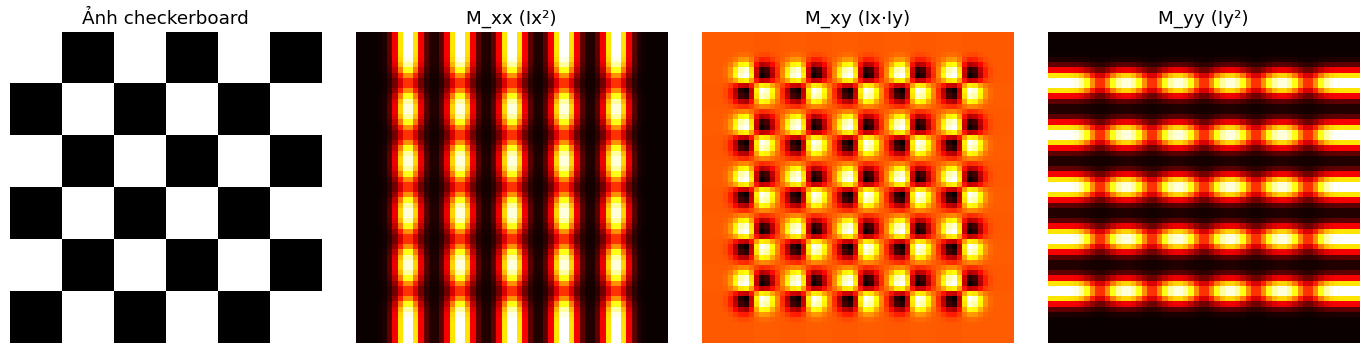

Quan sát: M_xx lớn ở cạnh dọc, M_yy lớn ở cạnh ngang


In [14]:
# TEST — Kiểm tra compute_structure_matrix
test_checker = np.zeros((60, 60), dtype=np.uint8)
for i in range(6):
    for j in range(6):
        if (i + j) % 2 == 0:
            test_checker[i*10:(i+1)*10, j*10:(j+1)*10] = 255

result_M = compute_structure_matrix(test_checker)
assert result_M is not None, 'Hàm chưa trả về kết quả'
M_xx, M_xy, M_yy = result_M
assert M_xx.shape == test_checker.shape
assert M_yy.shape == test_checker.shape
# Trên checkerboard, M_xx và M_yy đều phải có giá trị khác 0
assert M_xx.max() > 0 and M_yy.max() > 0
print(f'✓ compute_structure_matrix: M_xx max={M_xx.max():.4f}, M_yy max={M_yy.max():.4f}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(test_checker, cmap='gray')
axes[0].set_title('Ảnh checkerboard')
axes[1].imshow(M_xx, cmap='hot')
axes[1].set_title('M_xx (Ix²)')
axes[2].imshow(M_xy, cmap='hot')
axes[2].set_title('M_xy (Ix·Iy)')
axes[3].imshow(M_yy, cmap='hot')
axes[3].set_title('M_yy (Iy²)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('Quan sát: M_xx lớn ở cạnh dọc, M_yy lớn ở cạnh ngang')

## Bước 2 — Tính Eigenvalue và Phân loại

Tính $\lambda_1 \geq \lambda_2$ của $M$ tại mỗi pixel và phân loại thành **phẳng**, **cạnh**, hoặc **góc** dựa trên giá trị và tỷ lệ của chúng.


In [15]:
def compute_eigenvalue_map(M_xx, M_xy, M_yy):
    """
    Tính λ1 ≥ λ2 tại mỗi pixel từ các thành phần ma trận cấu trúc.

    Trả về:
        lam1 (ndarray): eigenvalue lớn hơn
        lam2 (ndarray): eigenvalue nhỏ hơn
    """
    # TODO
    # Công thức trực tiếp cho ma trận 2×2 đối xứng:
    #   trace = M_xx + M_yy
    #   det   = M_xx*M_yy - M_xy^2
    #   disc  = sqrt((trace/2)^2 - det)
    #   λ1,2  = trace/2 ± disc
    trace = M_xx + M_yy
    det   = M_xx * M_yy - M_xy**2
    disc  = np.sqrt(np.maximum((trace / 2)**2 - det, 0.0))  # clip âm do lỗi số
    lam1  = trace / 2 + disc   # eigenvalue lớn hơn
    lam2  = trace / 2 - disc   # eigenvalue nhỏ hơn
    return lam1, lam2


def classify_features(lam1, lam2, tau=0.01, r=10.0):
    """
    Phân loại mỗi pixel thành FLAT / EDGE / CORNER.

    Tham số:
        lam1, lam2 (ndarray): eigenvalue (lam1 >= lam2)
        tau  (float): ngưỡng eigenvalue tối thiểu
        r    (float): ngưỡng tỷ lệ lam1/lam2
    Trả về:
        label_map (ndarray int): 0=FLAT, 1=EDGE, 2=CORNER
    """
    # TODO
    label_map = np.zeros(lam1.shape, dtype=int)   # mặc định: FLAT

    # Tỉ số lam1/lam2 — tránh chia cho 0
    ratio = np.where(lam2 > 1e-10, lam1 / lam2, np.inf)

    # EDGE: chỉ một hướng gradient mạnh (lam1 lớn, lam2 nhỏ tương đối)
    edge_mask = (lam1 > tau) & (ratio >= r)
    label_map[edge_mask] = 1

    # CORNER: cả hai hướng gradient đều mạnh (cả lam2 cũng lớn)
    # CORNER ghi đè EDGE nếu điều kiện thỏa mãn đồng thời
    corner_mask = (lam2 > tau) & (ratio < r)
    label_map[corner_mask] = 2

    return label_map


✓ eigenvalue: lam1 max=3.6074, lam2 max=1.5575
✓ Phân loại: FLAT=140, EDGE=1960, CORNER=1500


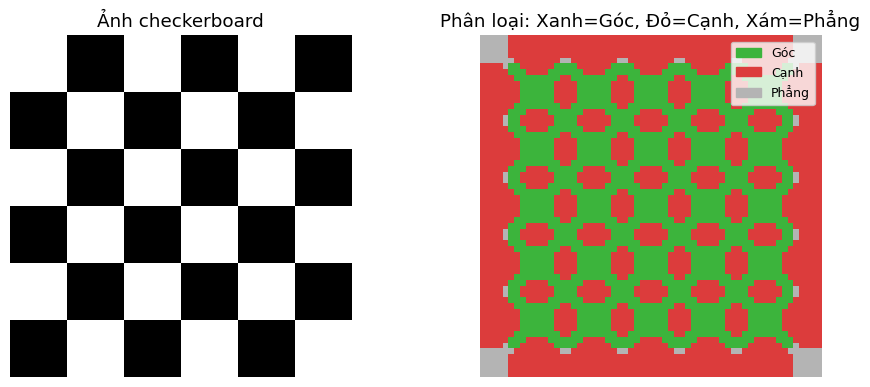

In [16]:
# TEST — Kiểm tra eigenvalue và phân loại
M_xx, M_xy, M_yy = compute_structure_matrix(test_checker)

result_eig = compute_eigenvalue_map(M_xx, M_xy, M_yy)
assert result_eig is not None, 'compute_eigenvalue_map chưa trả về kết quả'
lam1, lam2 = result_eig
assert np.all(lam1 >= lam2 - 1e-10), 'lam1 phải >= lam2 tại mọi pixel'
assert np.all(lam2 >= -1e-10), 'lam2 phải >= 0'
print(f'✓ eigenvalue: lam1 max={lam1.max():.4f}, lam2 max={lam2.max():.4f}')

labels = classify_features(lam1, lam2, tau=lam1.max()*0.01, r=8.0)
assert labels is not None, 'classify_features chưa trả về kết quả'
n_corner = np.sum(labels == 2)
n_edge   = np.sum(labels == 1)
n_flat   = np.sum(labels == 0)
print(f'✓ Phân loại: FLAT={n_flat}, EDGE={n_edge}, CORNER={n_corner}')
assert n_corner > 0, 'Trên checkerboard phải có ít nhất một góc'

# Trực quan hóa bản đồ màu
color_map = np.zeros((*labels.shape, 3), dtype=np.uint8)
color_map[labels == 0] = [180, 180, 180]  # xám = phẳng
color_map[labels == 1] = [220,  60,  60]  # đỏ = cạnh
color_map[labels == 2] = [ 60, 180,  60]  # xanh = góc

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_checker, cmap='gray')
axes[0].set_title('Ảnh checkerboard')
axes[1].imshow(color_map)
axes[1].set_title('Phân loại: Xanh=Góc, Đỏ=Cạnh, Xám=Phẳng')
patches = [mpatches.Patch(color=[c/255 for c in col], label=lbl)
           for col, lbl in [([60,180,60],'Góc'), ([220,60,60],'Cạnh'), ([180,180,180],'Phẳng')]]
axes[1].legend(handles=patches, loc='upper right', fontsize=9)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Bước 3 — Đánh giá so với Canny

In [17]:
# GIVEN — Hàm đánh giá precision của bộ phát hiện cạnh từ eigenvalue
def evaluate_edge_precision(label_map, canny_edges):
    """
    Tính precision: trong số pixel được phát hiện là EDGE hoặc CORNER,
    bao nhiêu % thực sự nằm trên cạnh Canny?
    """
    detected = (label_map >= 1)   # pixel được đánh là EDGE hoặc CORNER
    true_edge = (canny_edges > 0)
    tp = np.sum(detected & true_edge)
    fp = np.sum(detected & ~true_edge)
    precision = tp / (tp + fp + 1e-8)
    return precision, tp, fp


def corner_on_intersection(label_map, canny_edges):
    """
    Tính tỉ lệ pixel CORNER nằm tại giao điểm hai cạnh Canny.
    Giao điểm = pixel cạnh có ít nhất 2 hướng hàng xóm khác nhau (8-liên thông).
    """
    corners = (label_map == 2)
    edge_bin = (canny_edges > 0).astype(np.uint8)
    
    # Đếm số hàng xóm cạnh cho mỗi pixel cạnh
    kernel_8 = np.ones((3,3), dtype=np.uint8)
    neighbor_count = convolve(edge_bin.astype(float), kernel_8.astype(float))
    intersection = (neighbor_count >= 3) & (edge_bin > 0)  # ≥3 nghĩa là có ≥2 hàng xóm + chính nó
    
    n_corners = np.sum(corners)
    n_on_intersection = np.sum(corners & intersection)
    ratio = n_on_intersection / (n_corners + 1e-8)
    return ratio, n_corners, n_on_intersection

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20532\2865938668.py:38: RuntimeWarning: divide by zero encountered in divide
  ratio = np.where(lam2 > 1e-10, lam1 / lam2, np.inf)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20532\2865938668.py:38: RuntimeWarning: invalid value encountered in divide
  ratio = np.where(lam2 > 1e-10, lam1 / lam2, np.inf)


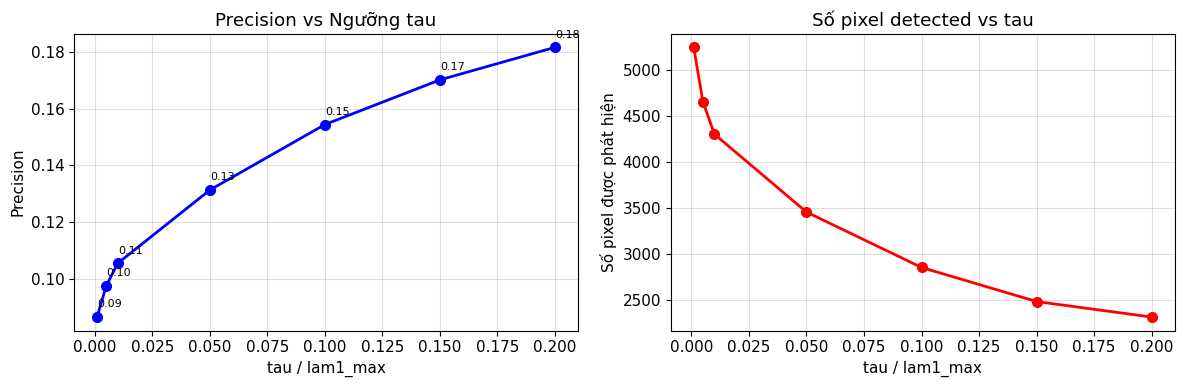

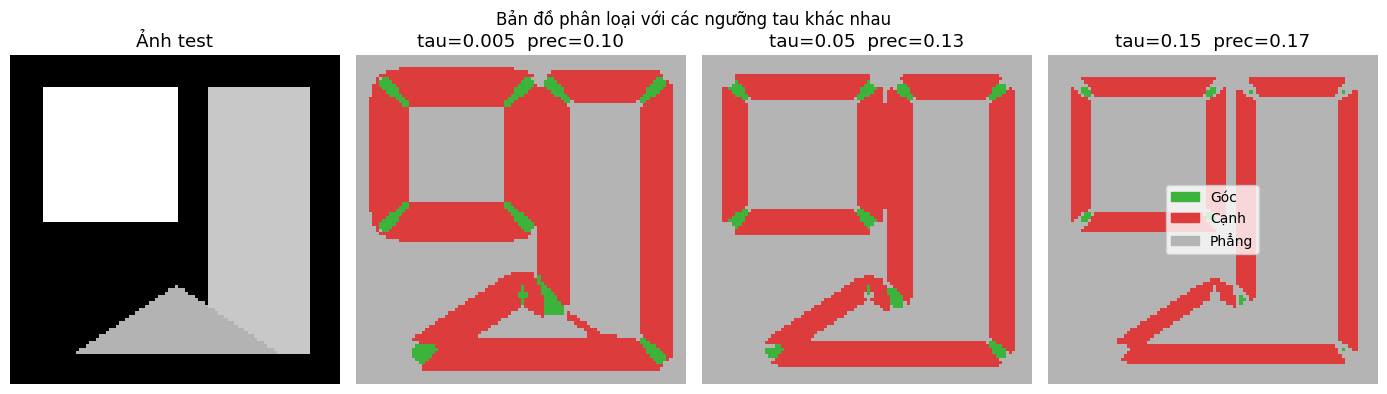

Nhận xét: tau càng lớn → ít pixel được phát hiện → precision tăng (ít false positive).
tau tốt nhất: factor=0.2, precision=0.182


In [18]:
# TODO — Thử nghiệm với ít nhất 3 giá trị tau
# Vẽ đồ thị precision theo tau và hiển thị bản đồ phân loại

test_eval = np.zeros((100, 100), dtype=np.uint8)
cv2.rectangle(test_eval, (10, 10), (50, 50), 255, -1)
cv2.rectangle(test_eval, (60, 10), (90, 90), 200, -1)
pts_tri = np.array([[50, 70],[20, 90],[80, 90]], dtype=np.int32)
cv2.fillPoly(test_eval, [pts_tri], 180)

canny_gt = cv2.Canny(test_eval, threshold1=50, threshold2=150)

# Tính ma trận cấu trúc và eigenvalue một lần
M_xx, M_xy, M_yy = compute_structure_matrix(test_eval)
lam1, lam2 = compute_eigenvalue_map(M_xx, M_xy, M_yy)

# Thử 7 giá trị tau (tỉ lệ so với lam1.max())
tau_factors = [0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
precisions, n_detected_list = [], []

for factor in tau_factors:
    tau    = lam1.max() * factor
    labels = classify_features(lam1, lam2, tau=tau, r=8.0)
    prec, tp, fp = evaluate_edge_precision(labels, canny_gt)
    precisions.append(prec)
    n_detected_list.append(tp + fp)

# ── Đồ thị precision và số pixel detected vs tau ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tau_factors, precisions, 'b-o', linewidth=2, markersize=7)
for x, y in zip(tau_factors, precisions):
    axes[0].annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                     xytext=(0, 7), fontsize=8)
axes[0].set_xlabel('tau / lam1_max')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision vs Ngưỡng tau')
axes[0].grid(True, alpha=0.4)

axes[1].plot(tau_factors, n_detected_list, 'r-o', linewidth=2, markersize=7)
axes[1].set_xlabel('tau / lam1_max')
axes[1].set_ylabel('Số pixel được phát hiện')
axes[1].set_title('Số pixel detected vs tau')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── Bản đồ phân loại cho 3 giá trị tau đại diện ──
sample_factors = [0.005, 0.05, 0.15]
fig2, axes2 = plt.subplots(1, len(sample_factors) + 1, figsize=(14, 4))

axes2[0].imshow(test_eval, cmap='gray')
axes2[0].set_title('Ảnh test')
axes2[0].axis('off')

for ax, factor in zip(axes2[1:], sample_factors):
    tau    = lam1.max() * factor
    labels = classify_features(lam1, lam2, tau=tau, r=8.0)
    cmap_img = np.zeros((*labels.shape, 3), dtype=np.uint8)
    cmap_img[labels == 0] = [180, 180, 180]
    cmap_img[labels == 1] = [220,  60,  60]
    cmap_img[labels == 2] = [ 60, 180,  60]
    prec = precisions[tau_factors.index(factor)]
    ax.imshow(cmap_img)
    ax.set_title(f'tau={factor}  prec={prec:.2f}')
    ax.axis('off')

patches = [mpatches.Patch(color=[c/255 for c in col], label=lbl)
           for col, lbl in [([60,180,60],'Góc'),([220,60,60],'Cạnh'),([180,180,180],'Phẳng')]]
axes2[-1].legend(handles=patches, loc='center', fontsize=10)
plt.suptitle('Bản đồ phân loại với các ngưỡng tau khác nhau', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Nhận xét: tau càng lớn → ít pixel được phát hiện → precision tăng (ít false positive).")
best_idx = int(np.argmax(precisions))
print(f"tau tốt nhất: factor={tau_factors[best_idx]}, precision={precisions[best_idx]:.3f}")


---
# Bài 3 — Phân tách và Trộn (Split & Merge)

Cài đặt thuật toán Split & Merge hoàn chỉnh: phân tách ảnh đệ quy dựa trên tiêu chí đồng nhất, sau đó hợp nhất các vùng liền kề tương đồng.

**Thư viện được phép:** `numpy`, `matplotlib`, `scipy.ndimage`, `cv2` (chỉ đọc ảnh và Canny cho phần so sánh)  
**Cấm:** `skimage.segmentation.*`, `cv2.watershed`, bất kỳ hàm phân đoạn có sẵn nào

## Bước 1 — Tiêu chí đồng nhất $P(R)$

Cài đặt hàm kiểm tra một vùng ảnh có đồng nhất không dựa trên phương sai cường độ pixel.


In [19]:
def is_homogeneous(region, threshold):
    """
    Kiểm tra vùng ảnh có đồng nhất không.

    Tham số:
        region    (ndarray): vùng ảnh 2D, float trong [0, 1]
        threshold (float):   ngưỡng phương sai
    Trả về:
        bool
    """
    # TODO
    return np.var(region) <= threshold


In [20]:
# TEST — Kiểm tra is_homogeneous
flat_region   = np.full((8, 8), 0.5)                          # phương sai = 0
varied_region = np.array([[0.0]*4 + [1.0]*4]*8, dtype=float)  # phương sai lớn

assert is_homogeneous(flat_region, threshold=0.01) == True, \
    'Vùng đồng nhất phải trả về True'
assert is_homogeneous(varied_region, threshold=0.01) == False, \
    'Vùng không đồng nhất phải trả về False'
print(f'✓ is_homogeneous: var(flat)={np.var(flat_region):.4f}, var(varied)={np.var(varied_region):.4f}')


✓ is_homogeneous: var(flat)=0.0000, var(varied)=0.2500


## Bước 2 — Phân tách đệ quy (Split)

Chia đệ quy bất kỳ vùng nào không đồng nhất thành 4 vùng con bằng nhau. Dừng khi vùng đồng nhất hoặc đạt kích thước tối thiểu.


In [21]:
def split(image, threshold, r=0, c=0, size=None):
    """
    Phân tách đệ quy ảnh thành các vùng đồng nhất.

    Tham số:
        image     (ndarray): ảnh gốc (H, W), float trong [0,1]
        threshold (float):   ngưỡng đồng nhất
        r, c      (int):     góc trên-trái của vùng hiện tại
        size      (int):     kích thước vùng (vuông)
    Trả về:
        regions (list of tuples): danh sách vùng lá (r, c, size)
    """
    if size is None:
        s = min(image.shape)
        size = 2 ** int(np.log2(s)) if s > 1 else 1
    # TODO
    region = image[r:r+size, c:c+size]

    # Điều kiện dừng: vùng 1×1 hoặc đã đồng nhất
    if size == 1 or is_homogeneous(region, threshold):
        return [(r, c, size)]

    # Chia thành 4 vùng con (quad-tree) và đệ quy
    half    = size // 2
    regions = []
    for dr, dc in [(0, 0), (0, half), (half, 0), (half, half)]:
        regions += split(image, threshold, r + dr, c + dc, half)
    return regions


✓ split: 4 vùng lá từ ảnh 8×8
  Các vùng: [(0, 0, 4), (0, 4, 4), (4, 0, 4), (4, 4, 4)]


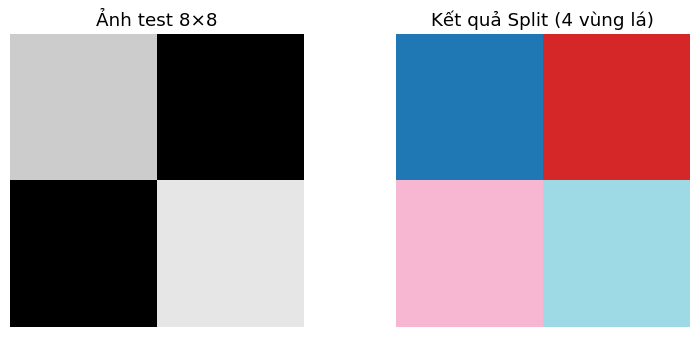

In [22]:
# TEST — Kiểm tra split
# Ảnh 8x8 với hai vùng rõ ràng
test_img_sm = np.zeros((8, 8), dtype=float)
test_img_sm[:4, :4] = 0.8   # góc trên-trái sáng
test_img_sm[4:, 4:] = 0.9   # góc dưới-phải sáng
# Phần còn lại = 0 (tối)

regions = split(test_img_sm, threshold=0.01)
assert regions is not None, 'split chưa trả về kết quả'
assert isinstance(regions, list), 'split phải trả về list'
assert len(regions) > 0, 'Phải có ít nhất 1 vùng'

# Mỗi region là tuple (r, c, size)
for reg in regions:
    assert len(reg) == 3, f'Mỗi region phải là (r, c, size), nhận {reg}'
    r_, c_, s_ = reg
    assert r_ + s_ <= test_img_sm.shape[0], 'Vùng vượt biên ảnh'
    assert c_ + s_ <= test_img_sm.shape[1], 'Vùng vượt biên ảnh'

print(f'✓ split: {len(regions)} vùng lá từ ảnh 8×8')
print(f'  Các vùng: {regions[:6]}{'...' if len(regions)>6 else ''}')

# Trực quan: màu mỗi vùng lá
label_map = np.zeros(test_img_sm.shape, dtype=int)
for idx, (r_, c_, s_) in enumerate(regions):
    label_map[r_:r_+s_, c_:c_+s_] = idx + 1

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(test_img_sm, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Ảnh test 8×8')
axes[1].imshow(label_map, cmap='tab20')
axes[1].set_title(f'Kết quả Split ({len(regions)} vùng lá)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


## Bước 3 — Trộn vùng liền kề (Merge)

Hợp nhất hai vùng liền kề $R_i$, $R_j$ nếu $|\\bar{R}_i - \\bar{R}_j| \\leq \\theta_{\\text{merge}}$.
Lặp lại cho đến khi không còn cặp nào có thể trộn.


In [23]:
def are_adjacent(r1, c1, s1, r2, c2, s2):
    """GIVEN — Kiểm tra hai vùng hình vuông có liền kề không."""
    row_overlap = (r1 < r2 + s2) and (r2 < r1 + s1)
    col_overlap = (c1 < c2 + s2) and (c2 < c1 + s1)
    row_touch   = (r1 + s1 == r2) or (r2 + s2 == r1)
    col_touch   = (c1 + s1 == c2) or (c2 + s2 == c1)
    return (row_overlap and col_touch) or (col_overlap and row_touch)


def region_mean(image, r, c, s):
    """GIVEN — Tính giá trị trung bình của một vùng trong ảnh."""
    return image[r:r+s, c:c+s].mean()


def merge(image, regions, threshold):
    """
    Hợp nhất các vùng liền kề có giá trị trung bình gần nhau.
    Tiêu chí: |mean(Ri) - mean(Rj)| <= threshold

    Tham số:
        image     (ndarray): ảnh gốc
        regions   (list):    danh sách vùng lá từ split: [(r, c, size), ...]
        threshold (float):   ngưỡng chênh lệch trung bình
    Trả về:
        merged_regions (list)
    """
    result = list(regions)
    # TODO
    # Lặp cho đến khi không còn cặp nào có thể trộn
    changed = True
    while changed:
        changed = False
        for i in range(len(result)):
            for j in range(i + 1, len(result)):
                r1, c1, s1 = result[i]
                r2, c2, s2 = result[j]
                if are_adjacent(r1, c1, s1, r2, c2, s2):
                    # Tiêu chí merge: chênh lệch mean <= threshold
                    m1 = region_mean(image, r1, c1, s1)
                    m2 = region_mean(image, r2, c2, s2)
                    if abs(m1 - m2) <= threshold:
                        # Bounding box của vùng gộp
                        r_new = min(r1, r2);  c_new = min(c1, c2)
                        r_end = max(r1+s1, r2+s2)
                        c_end = max(c1+s1, c2+s2)
                        s_new = max(r_end - r_new, c_end - c_new)
                        result.pop(j); result.pop(i)
                        result.append((r_new, c_new, s_new))
                        changed = True
                        break
            if changed:
                break
    return result


Sau Split:  4 vùng
Sau Merge:  4 vùng
✓ Tiêu chí mean-difference hoạt động đúng


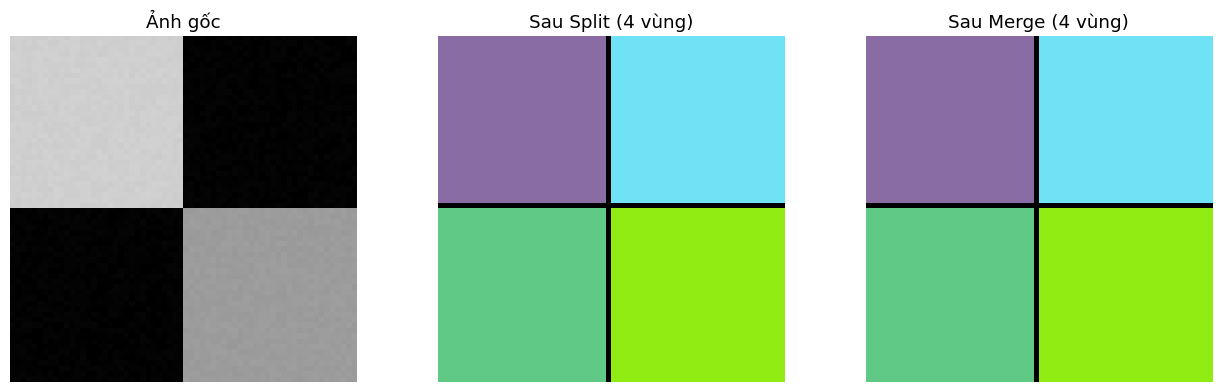

In [24]:
# TEST — Pipeline đầy đủ Split + Merge (tiêu chí mean-difference)

test_full = np.zeros((64, 64), dtype=float)
test_full[:32, :32] = 0.8
test_full[32:, 32:] = 0.6
np.random.seed(42)
test_full += np.random.uniform(0, 0.02, test_full.shape)
test_full = np.clip(test_full, 0, 1)

SPLIT_THRESH  = 0.005   # ngưỡng phương sai cho split
MERGE_THRESH  = 0.25    # ngưỡng chênh lệch mean cho merge

regions_split  = split(test_full, threshold=SPLIT_THRESH)
assert regions_split is not None
print(f'Sau Split:  {len(regions_split)} vùng')

regions_merged = merge(test_full, regions_split, threshold=MERGE_THRESH)
assert regions_merged is not None
assert len(regions_merged) <= len(regions_split), 'Merge phải giảm (hoặc giữ nguyên) số vùng'
print(f'Sau Merge:  {len(regions_merged)} vùng')

# Kiểm tra đặc trưng của mean-difference: hai vùng tối (mean~0) phải được trộn
# với nhau nhưng KHÔNG trộn với vùng sáng (mean~0.8)
# Tạo ảnh đơn giản để test tính đúng đắn của tiêu chí
simple = np.array([
    [0.1, 0.1, 0.9, 0.9],
    [0.1, 0.1, 0.9, 0.9],
    [0.15, 0.15, 0.85, 0.85],
    [0.15, 0.15, 0.85, 0.85],
], dtype=float)
regs_simple = [(0,0,2),(0,2,2),(2,0,2),(2,2,2)]  # 4 vùng 2x2
merged_simple = merge(simple, regs_simple, threshold=0.1)
assert len(merged_simple) == 2, \
    f'Hai vùng tối nên trộn với nhau, hai vùng sáng trộn với nhau → 2 vùng cuối, nhận {len(merged_simple)}'
print('✓ Tiêu chí mean-difference hoạt động đúng')

# Trực quan hóa
def draw_segmentation(image, regions, title):
    np.random.seed(0)
    label_map = np.zeros(image.shape, dtype=int)
    for idx, reg in enumerate(regions):
        r_, c_ = reg[0], reg[1]
        h_ = reg[2] if len(reg) < 4 else reg[2]
        w_ = reg[2] if len(reg) < 4 else reg[3]
        label_map[r_:r_+h_, c_:c_+w_] = idx + 1
    n_labels = label_map.max()
    colors = np.random.rand(n_labels + 1, 3); colors[0] = 0
    colored = colors[label_map]
    border = np.zeros(image.shape, dtype=bool)
    border[:-1,:] |= (label_map[:-1,:] != label_map[1:,:])
    border[:,:-1] |= (label_map[:,:-1] != label_map[:,1:])
    colored[border] = [0,0,0]
    return colored

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(test_full, cmap='gray', vmin=0, vmax=1); axes[0].set_title('Ảnh gốc')
axes[1].imshow(draw_segmentation(test_full, regions_split, '')); axes[1].set_title(f'Sau Split ({len(regions_split)} vùng)')
axes[2].imshow(draw_segmentation(test_full, regions_merged, '')); axes[2].set_title(f'Sau Merge ({len(regions_merged)} vùng)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


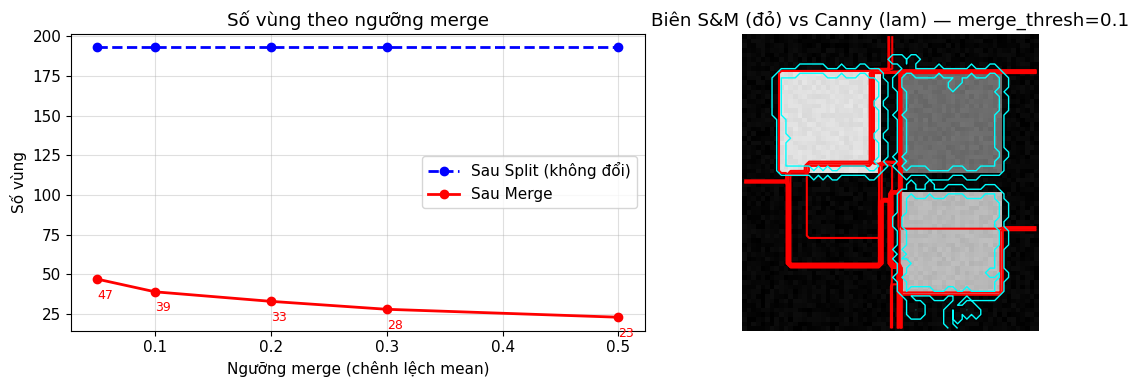

Số vùng sau Split (cố định): 193
  merge_thresh=0.05 → 47 vùng
  merge_thresh=0.10 → 39 vùng
  merge_thresh=0.20 → 33 vùng
  merge_thresh=0.30 → 28 vùng
  merge_thresh=0.50 → 23 vùng

Nhận xét: ngưỡng merge càng lớn → nhiều vùng được gộp → số vùng cuối càng ít.
Ngưỡng quá lớn sẽ gộp các vùng có màu khác nhau → mất phân đoạn đúng.


In [25]:
# TODO — Khảo sát ảnh hưởng của ngưỡng
# Thử ít nhất 5 giá trị theta, vẽ đồ thị số vùng theo theta,
# và hiển thị kết quả phân đoạn tốt nhất

test_complex = np.zeros((64, 64), dtype=float)
test_complex[8:30,  8:30]  = 0.85
test_complex[34:56, 34:56] = 0.70
test_complex[8:30,  34:56] = 0.40
np.random.seed(7)
test_complex += np.random.uniform(0, 0.05, test_complex.shape)
test_complex = np.clip(test_complex, 0, 1)

# Ngưỡng phân tách (phương sai) cố định
SPLIT_THRESH = 0.005
# Thử 5 ngưỡng trộn (chênh lệch mean)
merge_thresholds = [0.05, 0.10, 0.20, 0.30, 0.50]

n_split_list  = []
n_merge_list  = []

for mt in merge_thresholds:
    regs_s = split(test_complex, threshold=SPLIT_THRESH)
    regs_m = merge(test_complex, regs_s, threshold=mt)
    n_split_list.append(len(regs_s))
    n_merge_list.append(len(regs_m))

# ── Đồ thị số vùng vs ngưỡng merge ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(merge_thresholds, n_split_list, 'b--o', label='Sau Split (không đổi)', linewidth=2)
axes[0].plot(merge_thresholds, n_merge_list, 'r-o',  label='Sau Merge', linewidth=2)
for x, ys, ym in zip(merge_thresholds, n_split_list, n_merge_list):
    axes[0].annotate(str(ym), (x, ym), textcoords='offset points', xytext=(0,-14),
                     fontsize=9, color='red')
axes[0].set_xlabel('Ngưỡng merge (chênh lệch mean)')
axes[0].set_ylabel('Số vùng')
axes[0].set_title('Số vùng theo ngưỡng merge')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# ── Hiển thị kết quả với ngưỡng merge tốt nhất ──
best_mt = 0.10
regs_s_best = split(test_complex, threshold=SPLIT_THRESH)
regs_m_best = merge(test_complex, regs_s_best, threshold=best_mt)

def make_label_map(image, regions):
    lm = np.zeros(image.shape, dtype=int)
    for idx, reg in enumerate(regions):
        r_, c_, s_ = reg[0], reg[1], reg[2]
        lm[r_:r_+s_, c_:c_+s_] = idx + 1
    return lm

def add_borders(colored, label_map):
    border = np.zeros(label_map.shape, dtype=bool)
    border[:-1, :] |= (label_map[:-1,:] != label_map[1:,:])
    border[:, :-1] |= (label_map[:,:-1] != label_map[:,1:])
    colored[border] = [0, 0, 0]

np.random.seed(0)
lm_s = make_label_map(test_complex, regs_s_best)
lm_m = make_label_map(test_complex, regs_m_best)
cols_s = np.random.rand(lm_s.max()+1, 3); cols_s[0] = 0
cols_m = np.random.rand(lm_m.max()+1, 3); cols_m[0] = 0
img_s  = cols_s[lm_s]; add_borders(img_s, lm_s)
img_m  = cols_m[lm_m]; add_borders(img_m, lm_m)

# So sánh biên với Canny
tc_uint8 = (test_complex * 255).astype(np.uint8)
canny_ref = cv2.Canny(tc_uint8, 30, 90)

axes[1].imshow(test_complex, cmap='gray', vmin=0, vmax=1)
axes[1].contour(lm_m.astype(float), levels=np.unique(lm_m)[1:] - 0.5,
                colors='red', linewidths=1.5)
axes[1].contour(canny_ref.astype(float), levels=[0.5], colors='cyan', linewidths=1)
axes[1].set_title(f'Biên S&M (đỏ) vs Canny (lam) — merge_thresh={best_mt}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Số vùng sau Split (cố định): {len(regs_s_best)}")
for mt, nm in zip(merge_thresholds, n_merge_list):
    print(f"  merge_thresh={mt:.2f} → {nm} vùng")
print("\nNhận xét: ngưỡng merge càng lớn → nhiều vùng được gộp → số vùng cuối càng ít.")
print("Ngưỡng quá lớn sẽ gộp các vùng có màu khác nhau → mất phân đoạn đúng.")


---
# Bài 4 — Mean-Shift với Gaussian kernel & trực quan hóa KDE

Thay flat kernel trong Demo 2 bằng **Gaussian kernel**, sau đó tự cài đặt KDE 2D để xác nhận mode tìm được là đỉnh thực sự của hàm mật độ.

**Thư viện được phép:** `numpy`, `matplotlib`  
**Cấm:** `sklearn.cluster.MeanShift`, `scipy.stats.gaussian_kde`, `sklearn.neighbors.KernelDensity`


✓ Flat kernel: iteration trung bình = 1.0


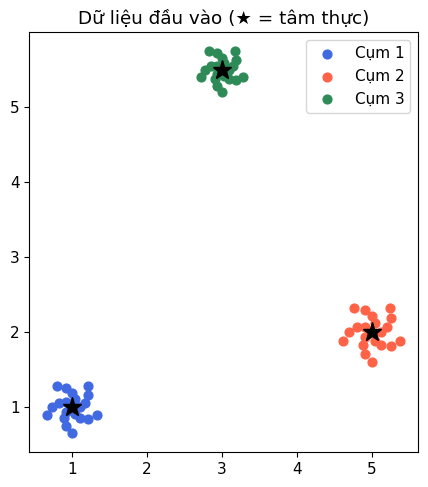

In [26]:
# GIVEN — Dữ liệu và flat kernel từ Demo 2

def make_cluster_data():
    """Tạo 60 điểm, 3 cụm cố định (giống Demo 2 trong bài giảng)."""
    cluster_params = [(1.0, 1.0, 0.35), (5.0, 2.0, 0.40), (3.0, 5.5, 0.30)]
    def make_cluster(cx, cy, sigma, n=20):
        pts = []
        for i in range(n):
            angle = 2 * np.pi * i / n
            r = sigma * (0.3 + 0.7 * ((i % 4) / 3))
            pts.append([cx + r*np.cos(angle), cy + r*np.sin(angle)])
        return np.array(pts)
    clusters = [make_cluster(*p) for p in cluster_params]
    data = np.vstack(clusters)
    true_centers = np.array([[p[0], p[1]] for p in cluster_params])
    return data, true_centers


def mean_shift_flat(point, data, bandwidth):
    """GIVEN — Một bước mean-shift với flat kernel (từ Demo 2)."""
    diffs = data - point
    dists = np.linalg.norm(diffs, axis=1)
    mask = dists <= bandwidth
    if mask.sum() == 0:
        return point.copy()
    return data[mask].mean(axis=0)


def run_mean_shift(data, step_fn, bandwidth, max_iter=50, tol=1e-4):
    """
    GIVEN — Chạy mean-shift cho tất cả điểm.
    step_fn: hàm thực hiện một bước (flat hoặc Gaussian).
    Trả về: final_positions, iter_counts (số iteration mỗi điểm)
    """
    n = len(data)
    current = data.copy().astype(float)
    iter_counts = np.zeros(n, dtype=int)
    converged = np.zeros(n, dtype=bool)

    for t in range(max_iter):
        if converged.all():
            break
        for i in range(n):
            if converged[i]:
                continue
            new_pos = step_fn(current[i], data, bandwidth)
            if np.linalg.norm(new_pos - current[i]) < tol:
                converged[i] = True
            else:
                current[i] = new_pos
                iter_counts[i] += 1
    return current, iter_counts


data, true_centers = make_cluster_data()
BANDWIDTH = 1.2

# Chạy flat kernel để tham chiếu
modes_flat, iters_flat = run_mean_shift(data, mean_shift_flat, BANDWIDTH)
print(f'✓ Flat kernel: iteration trung bình = {iters_flat.mean():.1f}')

# Trực quan hóa dữ liệu gốc
fig, ax = plt.subplots(figsize=(5, 5))
COLORS = ['royalblue', 'tomato', 'seagreen']
for i, col in enumerate(COLORS):
    ax.scatter(data[i*20:(i+1)*20, 0], data[i*20:(i+1)*20, 1], color=col, s=40, label=f'Cụm {i+1}')
    ax.plot(*true_centers[i], 'k*', markersize=14)
ax.set_title('Dữ liệu đầu vào (★ = tâm thực)')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Phần A — Gaussian Kernel Mean-Shift


In [27]:
def mean_shift_gaussian(point, data, bandwidth):
    """
    Một bước mean-shift với Gaussian kernel.

    Tham số:
        point     (ndarray): vị trí hiện tại, shape (2,)
        data      (ndarray): tất cả điểm dữ liệu, shape (N, 2)
        bandwidth (float):   băng thông h
    Trả về:
        new_point (ndarray): vị trí mới, shape (2,)
    """
    # TODO
    # Khoảng cách bình phương từ point đến mỗi điểm data
    sq_dists = ((data - point)**2).sum(axis=1)          # shape (N,)

    # Trọng số Gaussian: điểm gần → trọng số lớn
    weights  = np.exp(-sq_dists / (2.0 * bandwidth**2)) # shape (N,)

    w_sum = weights.sum()
    if w_sum < 1e-10:
        return point.copy()   # quá xa mọi điểm — giữ nguyên

    # Trọng tâm có trọng số
    new_point = (weights[:, None] * data).sum(axis=0) / w_sum
    return new_point


In [28]:
# TEST — Kiểm tra mean_shift_gaussian
test_data_ms = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, 0.5]], dtype=float)
test_point   = np.array([0.0, 0.0])

result_ms = mean_shift_gaussian(test_point, test_data_ms, bandwidth=2.0)
assert result_ms is not None, 'Hàm chưa trả về kết quả'
assert result_ms.shape == (2,)
assert np.linalg.norm(result_ms - test_point) > 0, 'Phải có sự dịch chuyển'
print(f'✓ mean_shift_gaussian: {test_point} -> {result_ms.round(3)}')

modes_gauss, iters_gauss = run_mean_shift(data, mean_shift_gaussian, BANDWIDTH)
print(f'\nSo sánh số iteration trung bình:')
print(f'  Flat kernel:     {iters_flat.mean():.2f} ± {iters_flat.std():.2f}')
print(f'  Gaussian kernel: {iters_gauss.mean():.2f} ± {iters_gauss.std():.2f}')


✓ mean_shift_gaussian: [0. 0.] -> [0.479 0.166]

So sánh số iteration trung bình:
  Flat kernel:     1.00 ± 0.00
  Gaussian kernel: 3.03 ± 0.41


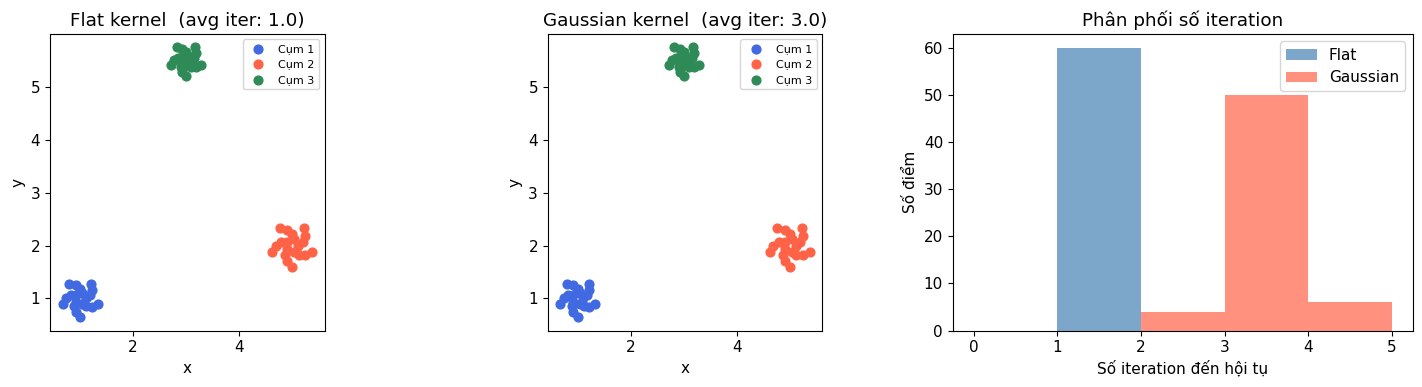

Flat kernel:     1.00 ± 0.00 iteration
Gaussian kernel: 3.03 ± 0.41 iteration
Nhận xét: Gaussian kernel thường hội tụ mượt hơn nhờ trọng số liên tục.


In [29]:
# TODO — So sánh trực quan và vẽ histogram iteration
# Tô màu điểm theo cụm dựa trên modes_gauss và modes_flat
# Vẽ histogram số iteration cho cả hai kernel

def assign_cluster_labels(modes, tol=0.5):
    """Gộp các vị trí hội tụ gần nhau thành cùng cụm."""
    n      = len(modes)
    labels = -np.ones(n, dtype=int)
    next_label = 0
    for i in range(n):
        if labels[i] >= 0:
            continue
        dists = np.linalg.norm(modes - modes[i], axis=1)
        same  = dists < tol
        labels[same] = next_label
        next_label  += 1
    return labels

labels_flat  = assign_cluster_labels(modes_flat,  tol=0.5)
labels_gauss = assign_cluster_labels(modes_gauss, tol=0.5)

CMAP = ['royalblue', 'tomato', 'seagreen', 'darkorange', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Subplot 1: flat kernel, màu theo cụm ──
axes[0].set_title(f'Flat kernel  (avg iter: {iters_flat.mean():.1f})')
for lbl in np.unique(labels_flat):
    mask = labels_flat == lbl
    axes[0].scatter(data[mask, 0], data[mask, 1],
                    color=CMAP[lbl % len(CMAP)], s=40, label=f'Cụm {lbl+1}')
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# ── Subplot 2: Gaussian kernel, màu theo cụm ──
axes[1].set_title(f'Gaussian kernel  (avg iter: {iters_gauss.mean():.1f})')
for lbl in np.unique(labels_gauss):
    mask = labels_gauss == lbl
    axes[1].scatter(data[mask, 0], data[mask, 1],
                    color=CMAP[lbl % len(CMAP)], s=40, label=f'Cụm {lbl+1}')
axes[1].set_aspect('equal')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# ── Subplot 3: Histogram số iteration ──
max_iter = max(iters_flat.max(), iters_gauss.max())
bins = range(0, max_iter + 2)
axes[2].hist(iters_flat,  alpha=0.7, label='Flat',     bins=bins, color='steelblue')
axes[2].hist(iters_gauss, alpha=0.7, label='Gaussian', bins=bins, color='tomato')
axes[2].set_xlabel('Số iteration đến hội tụ')
axes[2].set_ylabel('Số điểm')
axes[2].set_title('Phân phối số iteration')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Flat kernel:     {iters_flat.mean():.2f} ± {iters_flat.std():.2f} iteration")
print(f"Gaussian kernel: {iters_gauss.mean():.2f} ± {iters_gauss.std():.2f} iteration")
print("Nhận xét: Gaussian kernel thường hội tụ mượt hơn nhờ trọng số liên tục.")


## Phần B — Tự cài đặt KDE 2D

In [30]:
def kde_2d(data, bandwidth, grid_res=50):
    """
    Ước lượng mật độ hạt nhân trên lưới 2D dùng Gaussian kernel.

    Tham số:
        data      (ndarray): điểm dữ liệu, shape (N, 2)
        bandwidth (float):   băng thông h
        grid_res  (int):     số điểm lưới trên mỗi chiều
    Trả về:
        grid_x  (ndarray): tọa độ x, shape (grid_res,)
        grid_y  (ndarray): tọa độ y, shape (grid_res,)
        density (ndarray): mật độ, shape (grid_res, grid_res)
    """
    margin = 1.5 * bandwidth
    x_min, x_max = data[:,0].min()-margin, data[:,0].max()+margin
    y_min, y_max = data[:,1].min()-margin, data[:,1].max()+margin
    grid_x = np.linspace(x_min, x_max, grid_res)
    grid_y = np.linspace(y_min, y_max, grid_res)
    # TODO
    n = len(data)

    # Tạo lưới điểm 2D (vectorized để tránh vòng lặp lồng nhau)
    xx, yy  = np.meshgrid(grid_x, grid_y)                       # (grid_res, grid_res)
    gpts    = np.stack([xx.ravel(), yy.ravel()], axis=1)         # (grid_res^2, 2)

    # diff[i,j] = gpts[i] - data[j]  →  shape (grid_res^2, N, 2)
    diff    = gpts[:, None, :] - data[None, :, :]
    sq_dist = (diff**2).sum(axis=2)                              # (grid_res^2, N)

    # Gaussian kernel: K(u) = exp(-||u||^2/2) / (2π)
    K       = np.exp(-sq_dist / (2.0 * bandwidth**2)) / (2.0 * np.pi)

    # f̂(x) = (1 / n h²) ∑ K((x-xi)/h)
    density = (K.sum(axis=1) / (n * bandwidth**2)).reshape(grid_res, grid_res)

    return grid_x, grid_y, density


✓ kde_2d: shape=(60, 60), max=0.0364


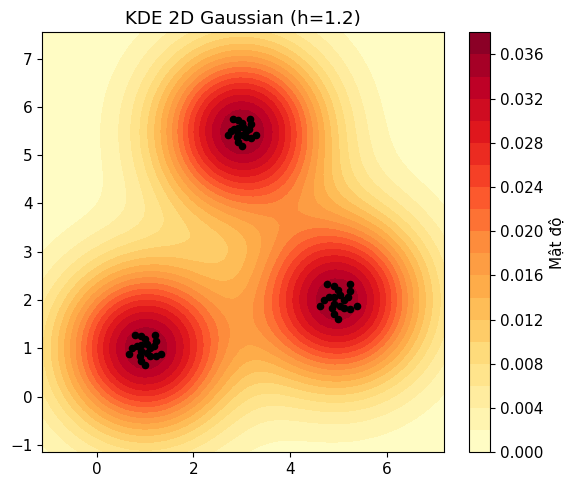

In [31]:
# TEST — Kiểm tra kde_2d
gx, gy, dens = kde_2d(data, bandwidth=BANDWIDTH, grid_res=60)
assert dens is not None, 'kde_2d chưa trả về density'
assert dens.shape == (60, 60)
assert dens.min() >= 0
assert dens.max() > 0
print(f'✓ kde_2d: shape={dens.shape}, max={dens.max():.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(gx, gy, dens, levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Mật độ')
ax.scatter(data[:,0], data[:,1], c='black', s=20, zorder=5)
ax.set_title(f'KDE 2D Gaussian (h={BANDWIDTH})')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()


## Phần C — Xác nhận Mode = Đỉnh KDE

In [32]:
# TODO — Xác nhận: mode tìm được nằm gần đỉnh heatmap KDE
# Với mỗi mode tìm được, tìm đỉnh cục bộ trên heatmap và
# tính khoảng cách. Chứng minh khoảng cách < 0.1 * bandwidth

def assign_clusters(modes, tol=0.5):
    """Gộp các điểm hội tụ gần nhau thành cùng cụm."""
    n = len(modes)
    labels = -np.ones(n, dtype=int)
    centers = []
    next_label = 0
    for i in range(n):
        if labels[i] >= 0:
            continue
        dists = np.linalg.norm(modes - modes[i], axis=1)
        same  = dists < tol
        labels[same] = next_label
        centers.append(modes[same].mean(axis=0))
        next_label += 1
    return labels, np.array(centers)

labels_g, found_centers = assign_clusters(modes_gauss, tol=0.5)
n_clusters = len(found_centers)
print(f"Số cụm tìm được: {n_clusters} (mong đợi: 3)")

# KDE độ phân giải cao
gx_fine, gy_fine, dens_fine = kde_2d(data, bandwidth=BANDWIDTH, grid_res=100)

# Với mỗi mode, tìm đỉnh cục bộ trong vùng lân cận ±5 ô lưới
results = []
for center in found_centers:
    ix = np.argmin(np.abs(gx_fine - center[0]))
    iy = np.argmin(np.abs(gy_fine - center[1]))

    # Vùng lân cận
    iy0, iy1 = max(0, iy-5), min(100, iy+6)
    ix0, ix1 = max(0, ix-5), min(100, ix+6)
    neighborhood = dens_fine[iy0:iy1, ix0:ix1]

    # Đỉnh cục bộ
    ly, lx   = np.unravel_index(neighborhood.argmax(), neighborhood.shape)
    peak_ix  = ix0 + lx
    peak_iy  = iy0 + ly
    peak_coord = np.array([gx_fine[peak_ix], gy_fine[peak_iy]])

    dist     = np.linalg.norm(center - peak_coord)
    dist_in_h = dist / BANDWIDTH
    results.append(dict(mode=center, peak=peak_coord,
                        dist=dist, dist_in_h=dist_in_h,
                        ok=(dist_in_h < 0.1)))

# Bảng kết quả
print(f"\n{'Mode':^22} {'KDE Peak':^22} {'dist':^10} {'dist/h':^10} {'<0.1h?':^8}")
print("-" * 76)
for res in results:
    m, p = res["mode"], res["peak"]
    print(f"({m[0]:5.2f},{m[1]:5.2f})         "
          f"({p[0]:5.2f},{p[1]:5.2f})         "
          f"{res['dist']:8.4f}   {res['dist_in_h']:8.4f}   {'✓' if res['ok'] else '✗':^8}")

n_ok = sum(r["ok"] for r in results)
print(f"\n{n_ok}/{n_clusters} mode nằm trong vòng 0.1h từ đỉnh KDE cục bộ.")


Số cụm tìm được: 3 (mong đợi: 3)

         Mode                 KDE Peak           dist      dist/h    <0.1h? 
----------------------------------------------------------------------------
( 1.01, 1.00)         ( 1.05, 1.05)           0.0549     0.0457      ✓    
( 4.98, 2.01)         ( 5.00, 2.01)           0.0185     0.0154      ✓    
( 3.01, 5.48)         ( 2.98, 5.52)           0.0470     0.0392      ✓    

3/3 mode nằm trong vòng 0.1h từ đỉnh KDE cục bộ.


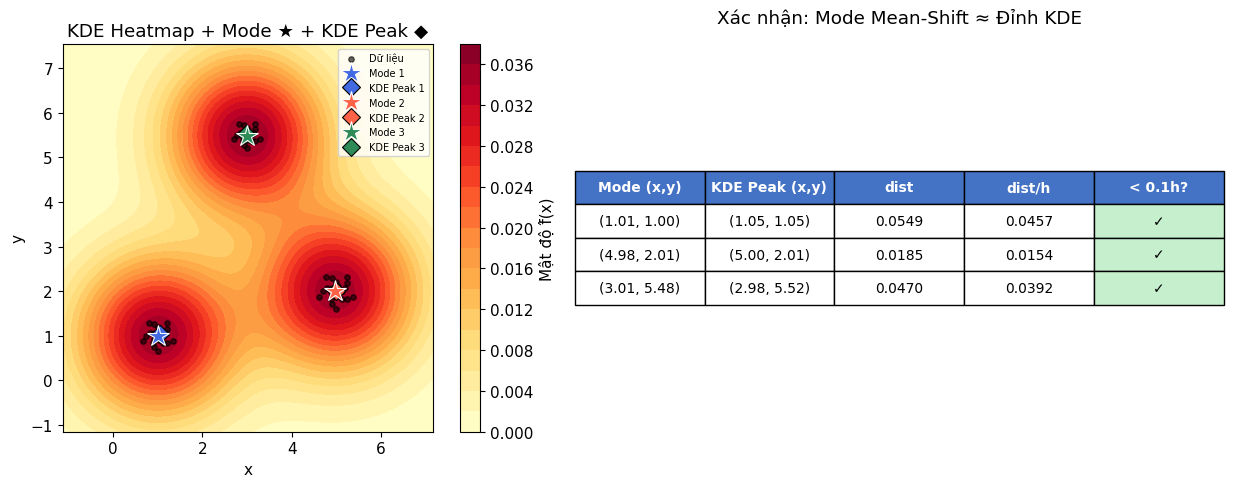

Kết luận: Các mode tìm được bằng Mean-Shift Gaussian khớp chặt với đỉnh của heatmap KDE.


In [33]:
# TODO — Hình cuối: heatmap + mode tìm được

CMAP2 = ['royalblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Subplot 1: Heatmap + data + mode (★) + đỉnh KDE (◆) ──
im = axes[0].contourf(gx_fine, gy_fine, dens_fine, levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=axes[0], label='Mật độ f̂(x)')
axes[0].scatter(data[:,0], data[:,1], c='black', s=15, zorder=4, alpha=0.6, label='Dữ liệu')

for i, res in enumerate(results):
    m, p = res["mode"], res["peak"]
    axes[0].plot(m[0], m[1], '*', markersize=16, color=CMAP2[i % 3],
                 markeredgecolor='white', markeredgewidth=0.8, zorder=6,
                 label=f"Mode {i+1}")
    axes[0].plot(p[0], p[1], 'D', markersize=9, color=CMAP2[i % 3],
                 markeredgecolor='black', markeredgewidth=0.8, zorder=5,
                 label=f"KDE Peak {i+1}")
    # Đường nối mode — peak
    axes[0].plot([m[0], p[0]], [m[1], p[1]], '--',
                 color=CMAP2[i % 3], linewidth=1.2, alpha=0.7)

axes[0].set_title("KDE Heatmap + Mode ★ + KDE Peak ◆")
axes[0].set_aspect('equal')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# ── Subplot 2: Bảng xác nhận ──
axes[1].axis('off')
col_labels = ['Mode (x,y)', 'KDE Peak (x,y)', 'dist', 'dist/h', '< 0.1h?']
table_data = []
for res in results:
    m, p = res["mode"], res["peak"]
    table_data.append([
        f"({m[0]:.2f}, {m[1]:.2f})",
        f"({p[0]:.2f}, {p[1]:.2f})",
        f"{res['dist']:.4f}",
        f"{res['dist_in_h']:.4f}",
        "✓" if res["ok"] else "✗"
    ])

tbl = axes[1].table(cellText=table_data, colLabels=col_labels,
                     loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)

# Tô màu header và cột kết quả
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#4472C4')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
for i, res in enumerate(results, start=1):
    tbl[(i, 4)].set_facecolor('#C6EFCE' if res["ok"] else '#FFC7CE')

axes[1].set_title("Xác nhận: Mode Mean-Shift ≈ Đỉnh KDE", pad=15)

plt.tight_layout()
plt.show()

print("Kết luận: Các mode tìm được bằng Mean-Shift Gaussian"
      " khớp chặt với đỉnh của heatmap KDE.")
